# SVM Training for Pneumonia Detection

This notebook trains an **SVM** (Support Vector Machine) classifier to classify chest X‑rays into three classes: **normal**, **bacteria**, **virus**.

## Tooling choices

- **scikit-learn**: SVM is a classical machine learning algorithm well-suited for image classification when combined with proper feature extraction. We use `sklearn.svm.SVC` with an RBF kernel.
- **PCA**: Since raw flattened images are high-dimensional, we use Principal Component Analysis to reduce dimensionality while retaining the most important variance in the data.
- **Grayscale conversion**: Chest X-rays are inherently grayscale, so we convert to single-channel to reduce feature space.

The data loaders and augmentations are defined in `prepocessing.ipynb` and will be executed here via `%run`.

## 1. Loading the augmentation pipeline

We **reuse** the `prepocessing.ipynb` notebook which:

- downloads the chest X‑ray dataset from Hugging Face,
- applies Albumentations augmentations,
- builds `train_loader`, `val_loader`, and `test_loader`.

This notebook focuses only on the **SVM model + training** part.

c:\Users\sh4rk\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Libraries imported successfully!

Augmentation pipelines created!

Loading dataset...


c:\Users\sh4rk\AppData\Local\Programs\Python\Python312\Lib\site-packages\albumentations\core\validation.py:114: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
  original_init(self, **validated_kwargs)
c:\Users\sh4rk\AppData\Local\Programs\Python\Python312\Lib\site-packages\huggingface_hub\file_download.py:129: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\sh4rk\.cache\huggingface\hub\datasets--PAR8--chest-xray-pneumonia. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator.


  Dataset loaded!
  Train: 4705 images
  Validation: 522 images
  Test: 624 images

 Transforms applied!
 Images will be augmented on-the-fly when you load them


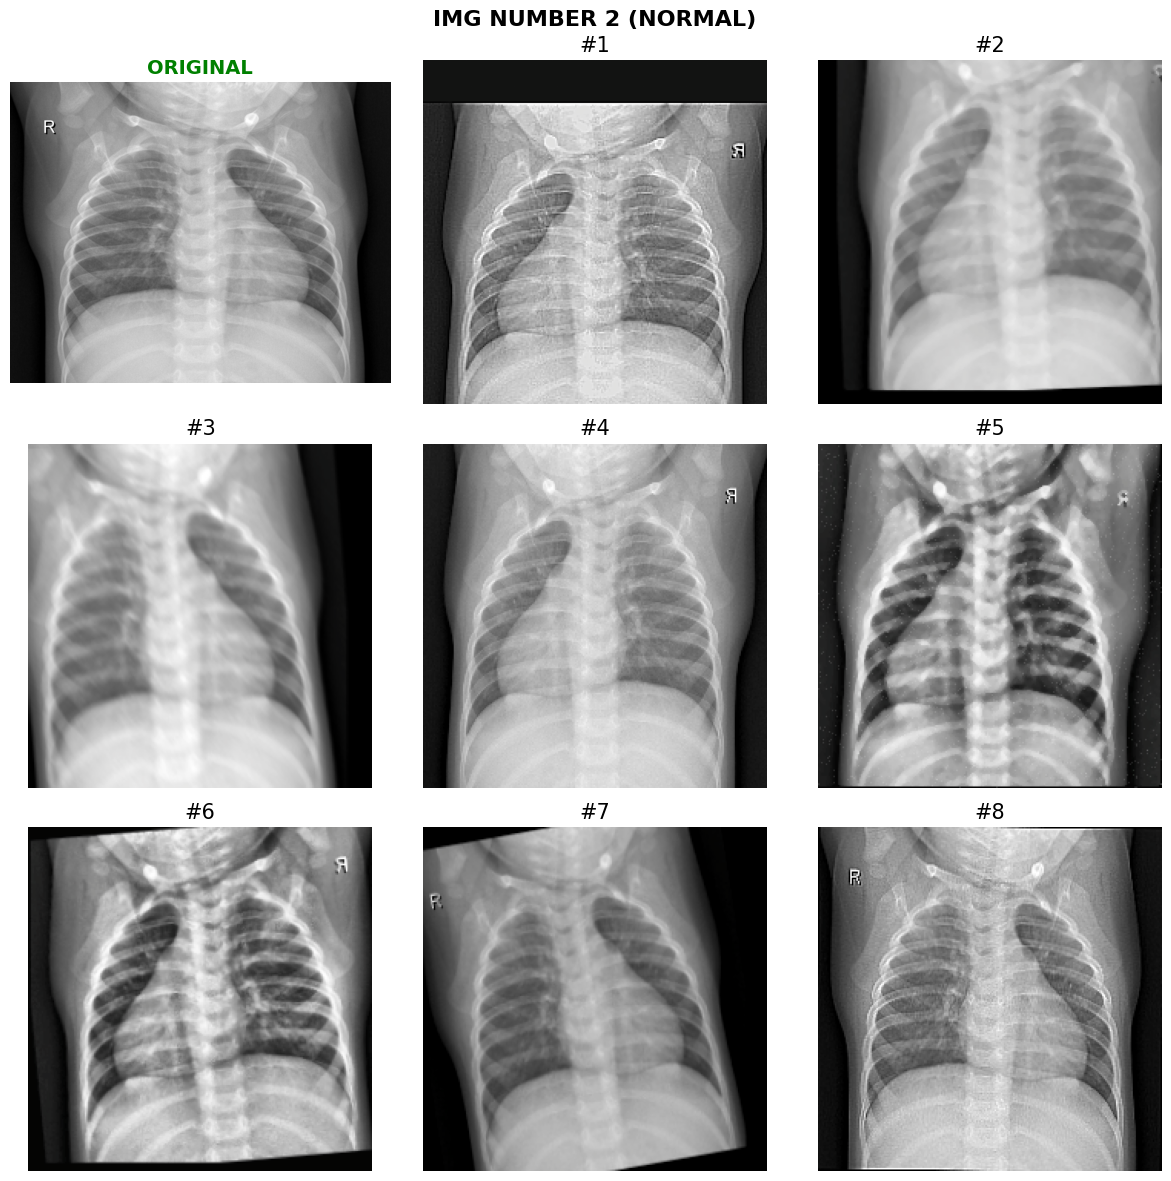


  DataLoaders ready!
  Batch size: 32
  Train batches: 148
  Val batches: 17
  Test batches: 20
Batch shape: torch.Size([32, 3, 224, 224])
Labels shape: torch.Size([32])

First 10 labels: [0, 1, 2, 0, 2, 0, 1, 0, 2, 0]
Label distribution: [10, 12, 10]


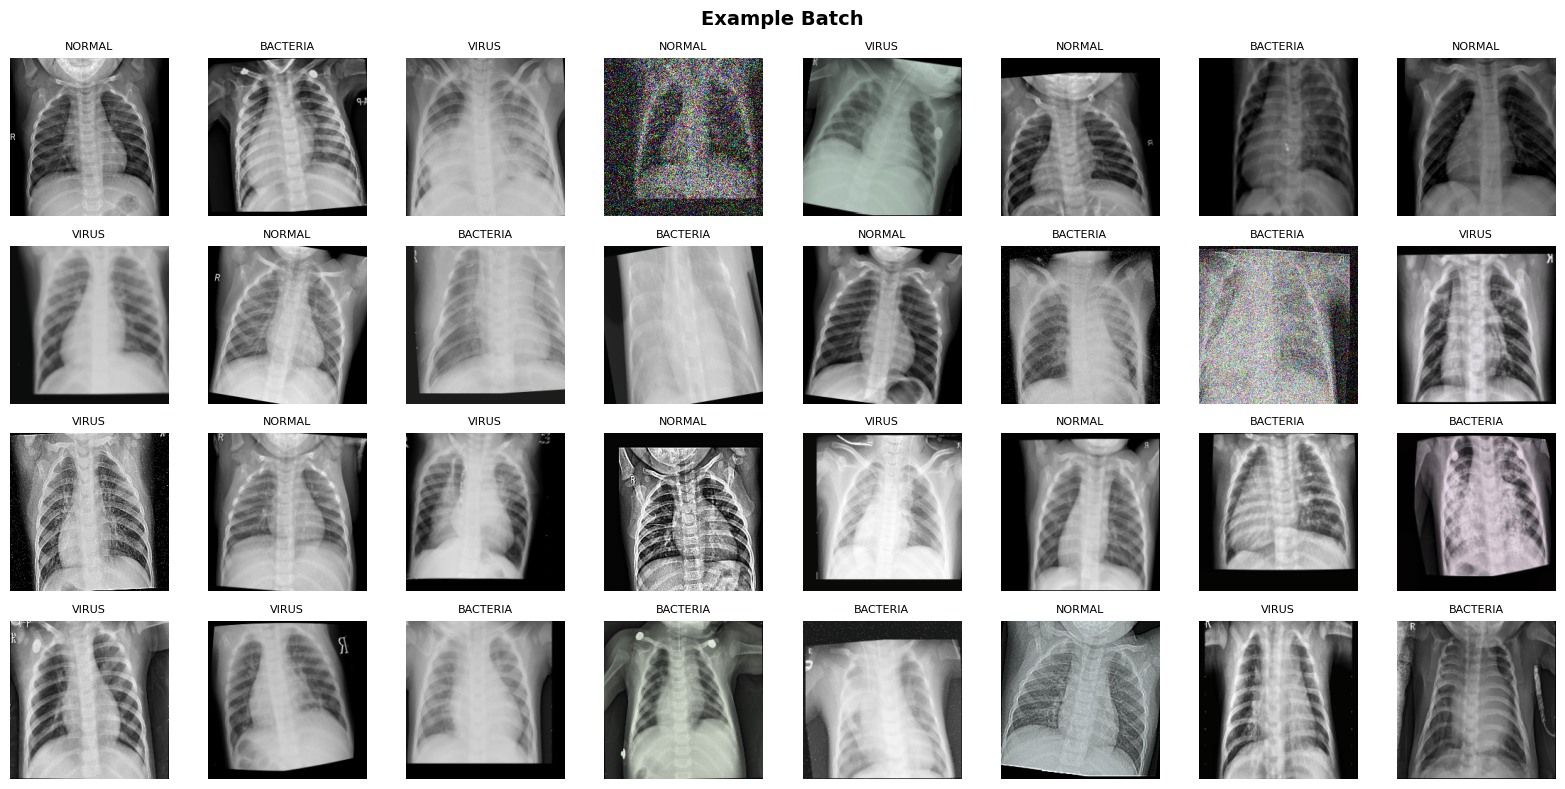

In [2]:
# Run the preprocessing notebook
# This defines: train_loader, val_loader, test_loader

%run "../prepocessing.ipynb"

## 2. Extracting features from DataLoaders

SVM operates on flat feature vectors, not 3D image tensors. We need to:

1. **Denormalize** the ImageNet-normalized tensors back to [0, 1] range,
2. **Convert to grayscale** (chest X‑rays are inherently grayscale, reducing features by 3×),
3. **Flatten** each image into a 1D vector of size 224 × 224 = 50 176.

We extract all images and labels from the DataLoaders into NumPy arrays.

In [3]:
import numpy as np
from tqdm.auto import tqdm

# ImageNet normalization constants
MEAN = np.array([0.485, 0.456, 0.406]).reshape(3, 1, 1)
STD = np.array([0.229, 0.224, 0.225]).reshape(3, 1, 1)

def extract_features(loader, desc="Extracting"):
    """Extract grayscale flattened features and labels from a DataLoader."""
    all_features = []
    all_labels = []

    for batch in tqdm(loader, desc=desc):
        images = batch["image"].numpy()  # (B, 3, 224, 224)
        labels = batch["label"].numpy()

        # Denormalize: tensor * std + mean -> [0, 1]
        images = images * STD + MEAN
        images = np.clip(images, 0, 1)

        # Convert to grayscale: 0.2989*R + 0.5870*G + 0.1140*B
        gray = 0.2989 * images[:, 0] + 0.5870 * images[:, 1] + 0.1140 * images[:, 2]
        # gray shape: (B, 224, 224)

        # Flatten each image to 1D
        flat = gray.reshape(gray.shape[0], -1)  # (B, 50176)

        all_features.append(flat)
        all_labels.append(labels)

    return np.concatenate(all_features), np.concatenate(all_labels)

# Extract features from train and validation sets
X_train, y_train = extract_features(train_loader, desc="Train")
X_val, y_val = extract_features(val_loader, desc="Val")

print(f"\nX_train shape: {X_train.shape}  |  y_train shape: {y_train.shape}")
print(f"X_val shape:   {X_val.shape}  |  y_val shape:   {y_val.shape}")
print(f"\nClass distribution (train): {np.bincount(y_train).tolist()}")
print(f"Class distribution (val):   {np.bincount(y_val).tolist()}")

Val: 100%|██████████| 17/17 [00:09<00:00,  1.74it/s]



X_train shape: (4705, 50176)  |  y_train shape: (4705,)
X_val shape:   (522, 50176)  |  y_val shape:   (522,)

Class distribution (train): [1175, 2362, 1168]
Class distribution (val):   [174, 174, 174]


## 3. Dimensionality reduction with PCA

With 50 176 features per image, SVM training would be extremely slow. We use **Principal Component Analysis (PCA)** to project each image into a lower-dimensional space while retaining 95 % of the total variance.

PCA is fitted on the **training set only**, then applied to both train and validation sets to avoid data leakage.

In [4]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# Standardize features before PCA (zero mean, unit variance)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)

# PCA: retain 95% of variance
pca = PCA(n_components=0.95, random_state=42)
X_train_pca = pca.fit_transform(X_train_scaled)
X_val_pca = pca.transform(X_val_scaled)

print(f"PCA components retained: {pca.n_components_}")
print(f"Explained variance:      {pca.explained_variance_ratio_.sum():.4f}")
print(f"\nX_train_pca shape: {X_train_pca.shape}")
print(f"X_val_pca shape:   {X_val_pca.shape}")
print(f"\nDimensionality reduction: {X_train.shape[1]} → {X_train_pca.shape[1]}")

PCA components retained: 900
Explained variance:      0.9500

X_train_pca shape: (4705, 900)
X_val_pca shape:   (522, 900)

Dimensionality reduction: 50176 → 900


## 4. Training the SVM classifier

We train an **SVM** with an **RBF (Radial Basis Function) kernel**, which is well suited for non-linearly separable data. The `probability=True` parameter enables probability estimates (needed later for ROC-AUC).

Key hyperparameters:
- **C** (regularization): controls the trade-off between margin width and classification errors,
- **gamma = "scale"**: kernel coefficient is set to `1 / (n_features × var(X))`, a good default for PCA-reduced data.

In [ ]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score
import time

# SVM with RBF kernel
svm = SVC(
    kernel="rbf",
    C=10,
    gamma="scale",
    probability=True,
    random_state=42,
    verbose=True
)

print("Training SVM...")
start_time = time.time()

svm.fit(X_train_pca, y_train)

elapsed = time.time() - start_time
print(f"\nTraining completed in {elapsed:.1f}s")

# Quick accuracy check on train and validation
train_acc = accuracy_score(y_train, svm.predict(X_train_pca))
val_acc = accuracy_score(y_val, svm.predict(X_val_pca))

print(f"\nTrain accuracy: {train_acc:.4f}")
print(f"Val accuracy:   {val_acc:.4f}")
print(f"\nSupport vectors: {svm.n_support_} (per class)")
print(f"Total support vectors: {svm.support_vectors_.shape[0]}")

Training SVM...
[LibSVM]
Training completed in 478.8s

Train accuracy: 0.9945
Val accuracy:   0.7797

Support vectors: [ 861 1875 1149] (per class)
Total support vectors: 3885


## 5. Saving the model pipeline

We save the complete pipeline (scaler + PCA + SVM) using `joblib` so that evaluation can be done independently in a separate notebook.

All three components are needed at inference time:
1. **Scaler**: standardizes raw pixel features,
2. **PCA**: projects into the reduced feature space,
3. **SVM**: classifies the reduced features.

In [6]:
import joblib

# Save the full pipeline
model_path = "./svm_pneumonia.joblib"
pipeline = {
    "scaler": scaler,
    "pca": pca,
    "svm": svm,
}
joblib.dump(pipeline, model_path)
print(f"Pipeline saved to {model_path}")

Pipeline saved to ./svm_pneumonia.joblib


## 6. Validation metrics and confusion matrix

Before moving to the test set (in the evaluation notebook), we check model performance on the **validation set** to get a first sense of generalization.

Classification report (validation set):
              precision    recall  f1-score   support

      normal       0.94      0.94      0.94       174
    bacteria       0.66      0.87      0.75       174
       virus       0.78      0.53      0.63       174

    accuracy                           0.78       522
   macro avg       0.79      0.78      0.77       522
weighted avg       0.79      0.78      0.77       522



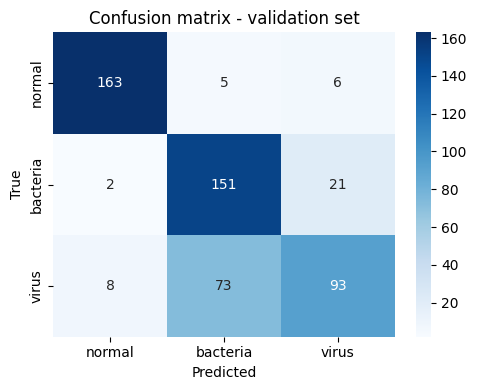

In [7]:
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

class_names = ["normal", "bacteria", "virus"]

# Predictions on validation set
val_preds = svm.predict(X_val_pca)

print("Classification report (validation set):")
print(classification_report(y_val, val_preds, target_names=class_names))

# Confusion matrix
cm = confusion_matrix(y_val, val_preds)

plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion matrix - validation set")
plt.tight_layout()
plt.show()